In [ ]:
# Cell 1: Setup
!apt-get install -y -q ffmpeg libsndfile1
!pip -q install torchaudio huggingface_hub "datasets<4.0.0" soundfile librosa einops omegaconf tqdm

import os
from pathlib import Path

if not Path("WavTokenizer").exists() and not Path("decoder").exists():
    !git clone -q https://github.com/jishengpeng/WavTokenizer.git
    os.chdir("WavTokenizer")
elif Path("WavTokenizer").exists():
    os.chdir("WavTokenizer")

import math, random, time, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import torchaudio
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# List available configs so we can pick the right one in Cell 2
print("\nAvailable configs:")
for p in sorted(Path("configs").glob("*.yaml")):
    print(f"  {p.name}")

Reading package lists...
Building dependency tree...
Reading state information...
libsndfile1 is already the newest version (1.0.31-2ubuntu0.2).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.6 MB/s eta 0:00:00
Device: cuda
GPU: NVIDIA A100-SXM4-40GB

Available configs:
  wavtokenizer_smalldata_frame40_3s_nq1_code4096_dim512_kmeans200_attn.yaml
  wavtokenizer_smalldata_frame75_3s_nq1_code4096_dim512_kmeans200_attn.yaml


In [ ]:
# Cell 2: Load WavTokenizer
from huggingface_hub import hf_hub_download
from decoder.pretrained import WavTokenizer

HF_REPO = "novateur/WavTokenizer"

# === PICK MODEL VARIANT ===
VARIANT = "320"  # "600" or "320"

VARIANTS = {
    "600": ("WavTokenizer_small_600_24k_4096.ckpt",
            "configs/wavtokenizer_smalldata_frame40_3s_nq1_code4096_dim512_kmeans200_attn.yaml"),
    "320": ("WavTokenizer_small_320_24k_4096.ckpt",
            "configs/wavtokenizer_smalldata_frame75_3s_nq1_code4096_dim512_kmeans200_attn.yaml"),
}

ckpt_name, cfg_path = VARIANTS[VARIANT]
ckpt_path = hf_hub_download(repo_id=HF_REPO, filename=ckpt_name)
print(f"Variant: {VARIANT}\nConfig: {cfg_path}\nCheckpoint: {ckpt_name}")

wavtokenizer = WavTokenizer.from_pretrained0802(cfg_path, ckpt_path).to(device).eval()

vq0 = wavtokenizer.feature_extractor.encodec.quantizer.vq.layers[0]
decoder = wavtokenizer.feature_extractor.encodec.decoder
codebook = vq0._codebook.embed.detach().clone()  # [M, D]
M, D = codebook.shape
print(f"Codebook: {M} codes × {D} dims")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


WavTokenizer_small_320_24k_4096.ckpt:   0%|          | 0.00/1.58G [00:00<?, ?B/s]

Variant: 320
Config: configs/wavtokenizer_smalldata_frame75_3s_nq1_code4096_dim512_kmeans200_attn.yaml
Checkpoint: WavTokenizer_small_320_24k_4096.ckpt


/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Codebook: 4096 codes × 512 dims


In [ ]:
# Cell 3: Extract latents preserving temporal order
from datasets import load_dataset

TARGET_SR = 24000
CHUNK_SEC = 3.0
CHUNK_LEN = int(TARGET_SR * CHUNK_SEC)
TARGET_LATENTS = 1500_000
BATCH_SIZE = 8

ds = load_dataset("parler-tts/libritts_r_filtered", "clean", split="train.clean.100", streaming=True)

def get_audio_chunk(example):
    audio = example["audio"]
    sr = audio["sampling_rate"]
    wav = torch.tensor(audio["array"], dtype=torch.float32)
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
    if wav.numel() < CHUNK_LEN:
        return None
    start = random.randint(0, wav.numel() - CHUNK_LEN)
    return wav[start:start + CHUNK_LEN]

# Hook to capture pre-VQ latents
captured = {}
def capture_hook(mod, inp, out):
    captured["u"] = out.detach()

hook = vq0.project_in.register_forward_hook(capture_hook)
bw_id = torch.tensor([0], device=device)

all_sequences = []  # list of [T, D] tensors, one per audio chunk
total_frames = 0
ds_iter = iter(ds.shuffle(seed=42, buffer_size=1000))
pbar = tqdm(total=TARGET_LATENTS, desc="Collecting latents")

with torch.no_grad():
    while total_frames < TARGET_LATENTS:
        wavs = []
        while len(wavs) < BATCH_SIZE:
            w = get_audio_chunk(next(ds_iter))
            if w is not None:
                wavs.append(w)

        captured.clear()
        _ = wavtokenizer.encode_infer(torch.stack(wavs).to(device), bandwidth_id=bw_id)
        u = captured["u"]  # [B, T, D] — preserve temporal structure

        for b in range(u.shape[0]):
            seq = u[b].cpu()  # [T, D]
            all_sequences.append(seq)
            total_frames += seq.shape[0]

        pbar.update(u.shape[0] * u.shape[1])

pbar.close()
hook.remove()

print(f"Collected {len(all_sequences)} sequences, {total_frames} total frames")
print(f"Frames per sequence: {all_sequences[0].shape[0]}")

# Split at sequence level
random.seed(42)
seq_idx = list(range(len(all_sequences)))
random.shuffle(seq_idx)
n_eval_seq = max(1, int(0.05 * len(all_sequences)))

eval_seq_idx = seq_idx[:n_eval_seq]
train_seq_idx = seq_idx[n_eval_seq:]

seq_train = [all_sequences[i].float() for i in train_seq_idx]
seq_eval = [all_sequences[i].float() for i in eval_seq_idx]

U_train = torch.cat(seq_train, dim=0)
U_eval = torch.cat(seq_eval, dim=0)

# Per-dimension normalization
u_mean = U_train.mean(0)
u_std = U_train.std(0).clamp(min=1e-4)
U_train_n = (U_train - u_mean) / u_std
U_eval_n = (U_eval - u_mean) / u_std

# Normalized eval sequences (for context building)
seq_eval_n = [(s - u_mean) / u_std for s in seq_eval]

print(f"Train: {len(seq_train)} seqs, {U_train_n.shape[0]} frames")
print(f"Eval:  {len(seq_eval)} seqs, {U_eval_n.shape[0]} frames")
print(f"mean(u_mean)={u_mean.mean():.4f}, mean(u_std)={u_std.mean():.4f}")

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/64 [00:00<?, ?it/s]

Collected 6672 sequences, 1501200 total frames
Frames per sequence: 225
Train: 6339 seqs, 1426275 frames
Eval:  333 seqs, 74925 frames
mean(u_mean)=-0.0009, mean(u_std)=0.2693


B_pca: (512, 6)
Top singular values: [4055.9504  2362.2578  1205.288   1128.1556   786.1715   441.64944]
Variance explained (top 6): 1.0000


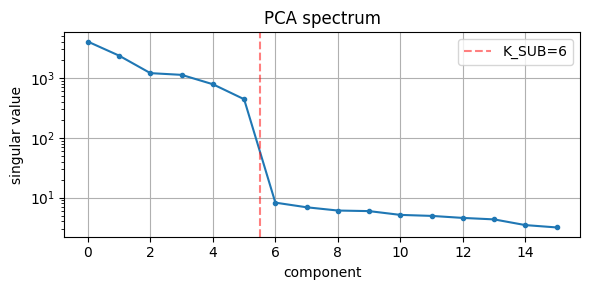

In [ ]:
# Cell 4: PCA on normalized latents
K_SUB = 6

PCA_N = min(50_000, U_train_n.shape[0])
X = U_train_n[torch.randperm(U_train_n.shape[0])[:PCA_N]].to(device)
X = X - X.mean(0, keepdim=True)

_, S, V = torch.pca_lowrank(X, q=K_SUB + 10, center=False)
B_pca = V[:, :K_SUB].contiguous()  # [512, K_SUB]
mu_pca = U_train_n.to(device).mean(0)

print(f"B_pca: {tuple(B_pca.shape)}")
print(f"Top singular values: {S[:K_SUB].cpu().numpy()}")
print(f"Variance explained (top {K_SUB}): {(S[:K_SUB]**2).sum() / (S**2).sum():.4f}")

# Quick spectrum plot
plt.figure(figsize=(6, 3))
plt.plot(S[:K_SUB+10].cpu().numpy(), marker=".")
plt.axvline(K_SUB - 0.5, color="r", ls="--", alpha=0.5, label=f"K_SUB={K_SUB}")
plt.yscale("log")
plt.xlabel("component")
plt.ylabel("singular value")
plt.title("PCA spectrum")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

  GN metric: 20/100
  GN metric: 40/100
  GN metric: 60/100
  GN metric: 80/100
  GN metric: 100/100

M_bar eigenvalues: [0.18972193 0.15049335 0.12943502 0.10939573 0.10798495 0.09025093]
Off-diag / diag ratio: 0.054


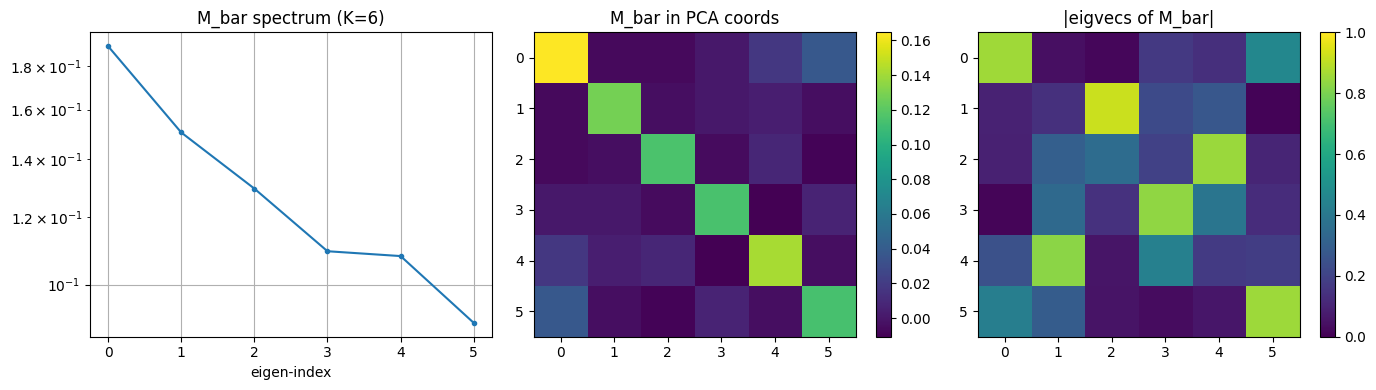

In [ ]:
# Cell 5: Pulled-back metric in PCA subspace via Gauss-Newton / JVP

u_mean_d = u_mean.to(device)
u_std_d = u_std.to(device)

# Decode from normalized latent sequence
def decode_u_norm_seq(u_norm_seq):
    """u_norm_seq: [1, T, 512] normalized → waveform [1, 1, T_audio]"""
    u = u_norm_seq * u_std_d + u_mean_d
    u_out = vq0.project_out(u)
    z = u_out.transpose(1, 2).contiguous()
    return decoder(z)

# Log-mel feature map
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SR, n_fft=1024, hop_length=256,
    n_mels=80, f_min=0.0, f_max=TARGET_SR / 2, power=2.0,
).to(device)
if hasattr(mel_transform, "spectrogram") and hasattr(mel_transform.spectrogram, "window"):
    mel_transform.spectrogram.window = mel_transform.spectrogram.window.to(device)

def feature_map(u_t, u_ctx, t):
    """Log-mel of decoded audio with u_t spliced into position t of u_ctx."""
    with torch.backends.cudnn.flags(enabled=False):
        u_seq = torch.cat([u_ctx[:, :t, :], u_t.view(1, 1, -1), u_ctx[:, t+1:, :]], dim=1)
        wav = decode_u_norm_seq(u_seq)[:, 0, :]
        return torch.log(mel_transform(wav) + 1e-6).reshape(-1)

def gn_metric_subspace(u_ctx, t, B_sub):
    """Gauss-Newton metric M = (J·B)ᵀ(J·B) in PCA subspace, shape [k, k]."""
    u0 = u_ctx[0, t, :].detach().clone().requires_grad_(True)
    f = lambda u: feature_map(u, u_ctx, t)
    cols = []
    for i in range(B_sub.shape[1]):
        _, Jv = torch.autograd.functional.jvp(f, (u0,), (B_sub[:, i].detach(),), create_graph=False, strict=True)
        cols.append(Jv)
    G = torch.stack(cols, dim=1)
    M = G.t() @ G
    return 0.5 * (M + M.t())

# Sample real temporal contexts from eval sequences
T_CTX = 15
t_target = T_CTX // 2
N_METRIC_SAMPLES = 100
B_sub = B_pca.to(device)

Ms = []
wavtokenizer.train()

for j in range(1, N_METRIC_SAMPLES + 1):
    seq = seq_eval_n[random.randint(0, len(seq_eval_n) - 1)]
    start = random.randint(0, seq.shape[0] - T_CTX - 1)
    u_ctx = seq[start:start + T_CTX].unsqueeze(0).to(device)
    Ms.append(gn_metric_subspace(u_ctx, t_target, B_sub).detach())
    if j % 20 == 0:
        print(f"  GN metric: {j}/{N_METRIC_SAMPLES}")

wavtokenizer.eval()

Ms = torch.stack(Ms)
M_bar = Ms.mean(0)
M_bar = 0.5 * (M_bar + M_bar.t())

# Eigenanalysis
eigvals, eigvecs = torch.linalg.eigh(M_bar)
eigvals = torch.clamp(eigvals, min=0)
idx = torch.argsort(eigvals, descending=True)
eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

offdiag = (M_bar - torch.diag(torch.diag(M_bar))).abs().mean().item()
diagmean = torch.diag(M_bar).abs().mean().item()

print(f"\nM_bar eigenvalues: {eigvals.cpu().numpy()}")
print(f"Off-diag / diag ratio: {offdiag / (diagmean + 1e-12):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(eigvals.cpu().numpy(), marker=".")
axes[0].set_yscale("log")
axes[0].set_title(f"M_bar spectrum (K={K_SUB})")
axes[0].set_xlabel("eigen-index")
axes[0].grid(True)

im1 = axes[1].imshow(M_bar.cpu().numpy(), aspect="auto")
plt.colorbar(im1, ax=axes[1])
axes[1].set_title("M_bar in PCA coords")

im2 = axes[2].imshow(np.abs(eigvecs.cpu().numpy()), aspect="auto", vmin=0, vmax=1)
plt.colorbar(im2, ax=axes[2])
axes[2].set_title("|eigvecs of M_bar|")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Build RD space (apply metric whitening)

REGIME = "mel"  # "mel" or "pca"

# Whitening transform: W = sqrt(Lambda) @ V^T so that ||Wz||^2 = z^T M_bar z
if REGIME == "mel":
    W = torch.diag(torch.sqrt(eigvals)) @ eigvecs.t()  # [k, k]
    print(f"Regime: mel — whitening with M_bar eigenvalues {eigvals.cpu().numpy()}")
elif REGIME == "pca":
    W = torch.eye(K_SUB, device=device)
    print("Regime: pca — identity whitening (Euclidean in PCA coords)")

# Project all data to final Z space
@torch.no_grad()
def to_Z(U_n, B_pca, mu_pca, W):
    Z_pca = (U_n.to(device).float() - mu_pca) @ B_pca
    return (Z_pca @ W.t()).contiguous()

Z_train = to_Z(U_train_n, B_pca, mu_pca, W)
Z_eval = to_Z(U_eval_n, B_pca, mu_pca, W)

# Codebook in same space
codebook_n = (codebook.float().cpu() - u_mean) / u_std
Z_codebook = to_Z(codebook_n, B_pca, mu_pca, W)

print(f"Z_train: {tuple(Z_train.shape)}, Z_eval: {tuple(Z_eval.shape)}, Z_codebook: {tuple(Z_codebook.shape)}")
print(f"Z_eval stats — mean: {Z_eval.mean(0).cpu().numpy()}, std: {Z_eval.std(0).cpu().numpy()}")

Regime: mel — whitening with M_bar eigenvalues [0.18972193 0.15049335 0.12943502 0.10939573 0.10798495 0.09025093]
Z_train: (1426275, 6), Z_eval: (74925, 6), Z_codebook: (4096, 6)
Z_eval stats — mean: [ 0.03703664 -0.01310814  0.04272225  0.00915255 -0.00566862  0.0075052 ], std: [6.8625546 1.5950878 3.5600352 1.9824352 2.0533626 2.5967677]


In [ ]:
# Cell 7: Blahut-Arimoto algorithm

LN2 = math.log(2.0)

@torch.no_grad()
def kmeanspp_init(Z, M, seed=0, chunk=8192):
    """KMeans++ seeding. Z: (N, k) → Y: (M, k)."""
    N, k = Z.shape
    g = torch.Generator(device=Z.device).manual_seed(seed)
    Y = torch.empty(M, k, device=Z.device)
    Y[0] = Z[torch.randint(0, N, (1,), generator=g, device=Z.device)]
    dmin = torch.full((N,), float("inf"), device=Z.device)

    for m in range(1, M):
        c = Y[m - 1:m]
        for s in range(0, N, chunk):
            d = ((Z[s:s + chunk] - c) ** 2).sum(-1)
            dmin[s:s + chunk] = torch.minimum(dmin[s:s + chunk], d)
        probs = dmin.clamp(min=1e-12)
        Y[m] = Z[torch.multinomial(probs / probs.sum(), 1, generator=g)]
        if m % 512 == 0:
            print(f"  kmeans++ init: {m}/{M}")
    return Y


@torch.no_grad()
def _ba_pass(Z, Y, logq, beta, chunk_N=2048):
    """One BA pass: update q, compute D and R. Returns (q_new, D, R_bits, num, den)."""
    N, k = Z.shape
    M = Y.shape[0]
    y2 = (Y * Y).sum(-1)

    q_acc = torch.zeros(M, device=Z.device)
    num = torch.zeros(M, k, device=Z.device)
    den = torch.zeros(M, device=Z.device)
    D_sum = 0.0
    I_sum = 0.0

    for s in range(0, N, chunk_N):
        z = Z[s:s + chunk_N]
        d = ((z * z).sum(-1, keepdim=True) + y2 - 2 * z @ Y.t()).clamp(min=0)
        logits = logq - beta * d
        lse = torch.logsumexp(logits, dim=1, keepdim=True)
        logp = logits - lse
        p = torch.exp(logp)

        q_acc += p.sum(0)
        num += p.t() @ z
        den += p.sum(0)
        D_sum += (p * d).sum().item()
        I_sum += (p * (logp - logq)).sum().item()

    q_new = (q_acc / N).clamp(min=1e-30)
    return q_new, D_sum / N, (I_sum / N) / LN2, num, den


@torch.no_grad()
def ba_solve(Z, beta, M=4096, Y_init=None, outer_iters=25, inner_iters=5,
             tol_q=1e-6, chunk_N=2048, update_support=True, verbose=False):
    """
    Blahut-Arimoto with optional support (centroid) updates.
    Returns dict with keys: Y, q, logq, D, R_bits.
    """
    N, k = Z.shape
    Y = Y_init.clone() if Y_init is not None else Z[torch.randperm(N)[:M]].clone()
    M = Y.shape[0]
    logq = torch.full((M,), -math.log(M), device=Z.device)

    for t in range(outer_iters):
        for _ in range(inner_iters):
            q_new, D, R_bits, num, den = _ba_pass(Z, Y, logq, beta, chunk_N)
            delta = (q_new - torch.exp(logq)).abs().max().item()
            logq = torch.log(q_new)
            if delta < tol_q:
                break

        if update_support:
            Y = (num / (den.unsqueeze(1) + 1e-12)).contiguous()

        if verbose:
            print(f"  [outer {t:02d}] D={D:.6f}  R={R_bits:.4f} bits  |Δq|={delta:.2e}")

        if delta < 1e-6:
            break

    _, D, R_bits, _, _ = _ba_pass(Z, Y, logq, beta, chunk_N)
    return {"Y": Y, "q": q_new, "logq": logq, "D": float(D), "R_bits": float(R_bits)}


@torch.no_grad()
def ba_sweep(Z, betas, M=4096, init="kmeans++", seed=0,
             outer_iters=25, inner_iters=5, chunk_N=2048,
             update_support=True, Y_fixed=None, verbose=False):
    """Sweep over betas with warm-start continuation. Returns DataFrame."""
    if Y_fixed is not None:
        Y_prev = Y_fixed.clone()
        print(f"BA sweep: fixed support M={Y_fixed.shape[0]}")
    elif init == "kmeans++":
        print(f"BA sweep: kmeans++ init M={M}")
        Y_prev = kmeanspp_init(Z, M, seed=seed)
    else:
        Y_prev = Z[torch.randperm(Z.shape[0])[:M]].clone()

    rows = []
    for beta in betas:
        print(f"  beta={beta:g} ...", end=" ")
        out = ba_solve(Z, beta, Y_init=Y_prev, outer_iters=outer_iters,
                       inner_iters=inner_iters, chunk_N=chunk_N,
                       update_support=update_support and (Y_fixed is None),
                       verbose=verbose)
        print(f"D={out['D']:.6f}  R={out['R_bits']:.4f} bits")
        rows.append({"beta": beta, "D": out["D"], "R_bits": out["R_bits"]})
        Y_prev = out["Y"]

    return pd.DataFrame(rows)

In [ ]:
# Cell 8: NERD model and training

# --- Closed-form log-integral for diagonal Gaussian components ---
def chunk_logI_diag(u, mu, sig, beta, need_delta=False):
    """
    log E_{y~N(mu,diag(sig^2))} exp(-beta||u-y||^2), computed in closed form.
    u: (B,k), mu: (K,k), sig: (K,k). Returns logI: (B,K), delta: (B,K) or None.
    """
    v = u[:, None, :] - mu[None, :, :]          # (B,K,k)
    a = 1.0 + 2.0 * beta * sig * sig            # (K,k)
    inv_a = 1.0 / a
    logI = -0.5 * torch.log(a).sum(-1) - beta * (v * v * inv_a).sum(-1)  # (B,K)
    if not need_delta:
        return logI, None
    delta = (v * v * (inv_a * inv_a)).sum(-1) + (sig * sig * inv_a).sum(-1)
    return logI, delta


# --- Network blocks ---
class RMSNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.w = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x * x.pow(2).mean(-1, keepdim=True).add(1e-8).rsqrt() * self.w

class SwiGLUBlock(nn.Module):
    def __init__(self, h, mult=4.0, res_scale=1.0):
        super().__init__()
        self.norm = RMSNorm(h)
        f = int(h * mult)
        self.fc = nn.Linear(h, 2 * f)
        self.out = nn.Linear(f, h)
        self.rs = res_scale
    def forward(self, x):
        y = self.norm(x)
        a, b = self.fc(y).chunk(2, -1)
        return x + self.rs * self.out(a * F.silu(b))

class NerdDiag(nn.Module):
    """NERD sampler: z ~ N(0,I) → (mu(z), sig(z)) defining mixture of diagonal Gaussians."""
    def __init__(self, z_dim, k_dim, hidden=512, depth=4, mult=4.0, min_std=1e-4, init_logsig=-4.0):
        super().__init__()
        self.z_dim = z_dim
        self.k_dim = k_dim
        self.min_std = min_std

        rs = 1.0 / math.sqrt(max(1, depth))
        self.inp = nn.Linear(z_dim, hidden)
        self.blocks = nn.ModuleList([SwiGLUBlock(hidden, mult, rs) for _ in range(depth)])
        self.norm = RMSNorm(hidden)
        self.mu_head = nn.Linear(hidden, k_dim)
        self.sig_head = nn.Linear(hidden, k_dim)
        nn.init.zeros_(self.sig_head.weight)
        nn.init.constant_(self.sig_head.bias, init_logsig)

    def forward(self, z):
        """z: (K, z_dim) → mu: (K, k_dim), sig: (K, k_dim)"""
        x = self.inp(z)
        for b in self.blocks:
            x = b(x)
        x = self.norm(x)
        return self.mu_head(x), F.softplus(self.sig_head(x)) + self.min_std


# --- Streaming log g_beta(u) ---
def stream_logg(model, u, beta, K, chunk_k=4096):
    """Differentiable estimate of log g_beta(u) = log E_Q exp(-beta||u-y||^2). Returns (B,)."""
    B = u.shape[0]
    m = torch.full((B,), -float("inf"), device=u.device)
    s = torch.zeros(B, device=u.device)

    for start in range(0, K, chunk_k):
        Kc = min(chunk_k, K - start)
        z = torch.randn(Kc, model.z_dim, device=u.device)
        with torch.amp.autocast("cuda", enabled=(u.device.type == "cuda"), dtype=torch.float16):
            mu, sig = model(z)
        logI, _ = chunk_logI_diag(u, mu, sig, beta)

        cmax = logI.max(1).values
        m_new = torch.maximum(m, cmax)
        s = torch.exp(m - m_new) * s + torch.exp(logI - m_new[:, None]).sum(1)
        m = m_new

    return torch.log(s) + m - math.log(K)


@torch.no_grad()
def nerd_eval(model, u, beta, Z_grid, chunk_k=4096):
    """Deterministic eval on fixed grid. Returns dict with D, R_bits, ess."""
    model.eval()
    B, K = u.shape[0], Z_grid.shape[0]

    m = torch.full((B,), -float("inf"), device=u.device)
    s1 = torch.zeros(B, device=u.device)
    s2 = torch.zeros(B, device=u.device)
    sd = torch.zeros(B, device=u.device)

    for start in range(0, K, chunk_k):
        Kc = min(chunk_k, K - start)
        with torch.amp.autocast("cuda", enabled=(u.device.type == "cuda"), dtype=torch.float16):
            mu, sig = model(Z_grid[start:start + Kc])
        logI, delta = chunk_logI_diag(u, mu, sig, beta, need_delta=True)

        cmax = logI.max(1).values
        m_new = torch.maximum(m, cmax)
        r = torch.exp(m - m_new)
        e = torch.exp(logI - m_new[:, None])

        s1 = s1 * r + e.sum(1)
        s2 = s2 * r * r + (e * e).sum(1)
        sd = sd * r + (e * delta).sum(1)
        m = m_new

    logg = torch.log(s1) + m - math.log(K)
    D = (sd / (s1 + 1e-12)).mean().item()
    R_bits = (-beta * D - logg.mean().item()) / LN2
    ess = (s1 * s1 / (s2 + 1e-12)).mean().item()
    return {"D": D, "R_bits": R_bits, "ess": ess}


def train_nerd(model, beta, Z_train, Z_eval, steps=2000, lr=2e-4, wd=1e-4,
               batch_u=2048, K=32768, chunk_k=4096, eval_every=250, Z_grid=None):
    """Train NERD at fixed beta. Returns (model, final_eval_dict)."""
    if Z_grid is None:
        Z_grid = torch.randn(K, model.z_dim, device=device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    ev = nerd_eval(model, Z_eval, beta, Z_grid, chunk_k)
    print(f"  [init] D={ev['D']:.4f}  R={ev['R_bits']:.2f} bits  ESS={ev['ess']:.1f}")

    t0 = time.time()
    for step in range(1, steps + 1):
        model.train()
        idx = torch.randint(0, Z_train.shape[0], (batch_u,), device=device)
        loss = -stream_logg(model, Z_train[idx], beta, K, chunk_k).mean()

        opt.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()

        if step % eval_every == 0 or step == steps:
            ev = nerd_eval(model, Z_eval, beta, Z_grid, chunk_k)
            print(f"  [{step:5d}] loss={loss.item():.4f}  D={ev['D']:.4f}  R={ev['R_bits']:.2f} bits  ESS={ev['ess']:.1f}")

    print(f"  Done beta={beta:g} in {(time.time() - t0) / 60:.1f} min")
    return model, nerd_eval(model, Z_eval, beta, Z_grid, chunk_k)

In [ ]:
# Cell 9: Run BA sweep

BETAS_BA = [0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0, 10, 20, 50]
M_BA = 16000

Z_src = Z_eval.to(device).float().contiguous()

df_ba = ba_sweep(Z_src, BETAS_BA, M=M_BA, init="kmeans++", seed=0,
                 outer_iters=20, inner_iters=8, chunk_N=2048,
                 update_support=True, verbose=False)

# Plot
df_plot = df_ba.sort_values("D")
plt.figure(figsize=(7, 4))
plt.plot(df_plot["D"], df_plot["R_bits"], marker="o")
for _, r in df_plot.iterrows():
    plt.text(r["D"], r["R_bits"], f" β={r['beta']:g}", fontsize=8)
plt.xlabel("D (whitened Z-space)")
plt.ylabel("R (bits)")
plt.title("BA R(D) curve")
plt.grid(True)
plt.tight_layout()
plt.show()

print(df_ba)

BA sweep: kmeans++ init M=16000
  kmeans++ init: 512/16000
  kmeans++ init: 1024/16000
  kmeans++ init: 1536/16000
  kmeans++ init: 2048/16000
  kmeans++ init: 2560/16000
  kmeans++ init: 3072/16000
  kmeans++ init: 3584/16000
  kmeans++ init: 4096/16000
  kmeans++ init: 4608/16000
  kmeans++ init: 5120/16000
  kmeans++ init: 5632/16000
  kmeans++ init: 6144/16000
  kmeans++ init: 6656/16000
  kmeans++ init: 7168/16000
  kmeans++ init: 7680/16000
  kmeans++ init: 8192/16000
  kmeans++ init: 8704/16000
  kmeans++ init: 9216/16000
  kmeans++ init: 9728/16000
  kmeans++ init: 10240/16000
  kmeans++ init: 10752/16000
  kmeans++ init: 11264/16000
  kmeans++ init: 11776/16000
  kmeans++ init: 12288/16000
  kmeans++ init: 12800/16000
  kmeans++ init: 13312/16000
  kmeans++ init: 13824/16000
  kmeans++ init: 14336/16000
  kmeans++ init: 14848/16000
  kmeans++ init: 15360/16000
  kmeans++ init: 15872/16000
  beta=0.2 ... D=10.862066  R=3.6240 bits
  beta=0.3 ... 

In [ ]:
# Cell 10: Run NERD sweep + overlay with BA

BETAS_NERD = [0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0]
Z_DIM = 32
K_COMP = 32768
STEPS = 2000

k_dim = Z_train.shape[1]
Z_grid = torch.randn(K_COMP, Z_DIM, device=device)

model = NerdDiag(z_dim=Z_DIM, k_dim=k_dim, hidden=512, depth=4).to(device)

rows = []
for i, beta in enumerate(BETAS_NERD):
    print(f"\n{'='*50}")
    print(f"NERD {i+1}/{len(BETAS_NERD)}  beta={beta:g}")
    print(f"{'='*50}")
    model, ev = train_nerd(model, beta, Z_train, Z_eval,
                           steps=STEPS, batch_u=2048, K=K_COMP,
                           chunk_k=4096, eval_every=500, Z_grid=Z_grid)
    rows.append({"beta": beta, "D": ev["D"], "R_bits": ev["R_bits"], "ess": ev["ess"]})

df_nerd = pd.DataFrame(rows)

# Plot overlay
plt.figure(figsize=(8, 5))

dfn = df_nerd.sort_values("D")
dfb = df_ba.sort_values("D")
plt.plot(dfn["D"], dfn["R_bits"], marker="o", label="NERD")
plt.plot(dfb["D"], dfb["R_bits"], marker="s", label="BA")

for _, r in dfn.iterrows():
    plt.text(r["D"], r["R_bits"], f" β={r['beta']:g}", fontsize=7, color="C0")
for _, r in dfb.iterrows():
    plt.text(r["D"], r["R_bits"], f" β={r['beta']:g}", fontsize=7, color="C1")

plt.xlabel("D (whitened Z-space)")
plt.ylabel("R (bits)")
plt.title("R(D): NERD vs BA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nNERD:")
print(df_nerd)
print("\nBA:")
print(df_ba)

NameError: name 'Z_train' is not defined

In [ ]:
# Cell 11: Extract BA codebook at target beta

BETA_EXTRACT = 10.0
M_EXTRACT = 4096

Z_src = Z_eval.to(device).float().contiguous()

print(f"Running BA at beta={BETA_EXTRACT} with M={M_EXTRACT} ...")
Y0 = kmeanspp_init(Z_src, M_EXTRACT, seed=0)
out = ba_solve(Z_src, BETA_EXTRACT, Y_init=Y0,
               outer_iters=25, inner_iters=10, chunk_N=2048,
               update_support=True, verbose=True)

Y_BA_Z = out["Y"].detach().contiguous()
q_ba = out["q"].detach()

print(f"\nBA codebook: D={out['D']:.6f}  R={out['R_bits']:.4f} bits")
print(f"q stats: min={q_ba.min():.3e}  median={q_ba.median():.3e}  max={q_ba.max():.3e}")

# Entropy / perplexity of BA codebook usage
H_ba = float(-(q_ba * torch.log2(q_ba + 1e-30)).sum().item())
print(f"Entropy: {H_ba:.2f} bits  Perplexity: {2**H_ba:.0f}")

Running BA at beta=20.0 with M=16000 ...
  kmeans++ init: 512/16000
  kmeans++ init: 1024/16000
  kmeans++ init: 1536/16000
  kmeans++ init: 2048/16000
  kmeans++ init: 2560/16000
  kmeans++ init: 3072/16000
  kmeans++ init: 3584/16000
  kmeans++ init: 4096/16000
  kmeans++ init: 4608/16000
  kmeans++ init: 5120/16000
  kmeans++ init: 5632/16000
  kmeans++ init: 6144/16000
  kmeans++ init: 6656/16000
  kmeans++ init: 7168/16000
  kmeans++ init: 7680/16000
  kmeans++ init: 8192/16000
  kmeans++ init: 8704/16000
  kmeans++ init: 9216/16000
  kmeans++ init: 9728/16000
  kmeans++ init: 10240/16000
  kmeans++ init: 10752/16000
  kmeans++ init: 11264/16000
  kmeans++ init: 11776/16000
  kmeans++ init: 12288/16000
  kmeans++ init: 12800/16000
  kmeans++ init: 13312/16000
  kmeans++ init: 13824/16000
  kmeans++ init: 14336/16000
  kmeans++ init: 14848/16000
  kmeans++ init: 15360/16000
  kmeans++ init: 15872/16000
  [outer 00] D=0.000534  R=13.8369 bits  |Δq|=2.86e-06
  [outer 01] D=0.000608  

In [ ]:
# Cell 12: BA vs VQ — each method uses its native NN metric

Winv_t = torch.linalg.inv(W).t().contiguous()

@torch.no_grad()
def z_to_u_norm(z_fin):
    if z_fin.dim() == 1: z_fin = z_fin[None, :]
    return mu_pca + (z_fin @ Winv_t) @ B_pca.t()

CB_u_norm = ((codebook.to(device).float() - u_mean_d) / u_std_d).contiguous()

# Codebook in PCA space (unwhitened) for VQ assignment
Z_codebook_pca = ((CB_u_norm - mu_pca) @ B_pca).contiguous()

@torch.no_grad()
def decode_seq(u_norm_seq):
    u = u_norm_seq * u_std_d + u_mean_d
    u_out = vq0.project_out(u)
    return decoder(u_out.transpose(1, 2).contiguous())

@torch.no_grad()
def logmel(wav):
    return torch.log(mel_transform(wav[:, 0, :]) + 1e-6)

@torch.no_grad()
def nearest_batch(Z, C, chunk=256):
    """Nearest neighbor. Z: (T,k), C: (M,k)"""
    T = Z.shape[0]
    c2 = (C * C).sum(-1)
    idx_all = torch.empty(T, dtype=torch.long, device=Z.device)
    dmin_all = torch.empty(T, device=Z.device)
    for s in range(0, T, chunk):
        z = Z[s:s+chunk]
        d = ((z * z).sum(-1, keepdim=True) + c2 - 2 * z @ C.t()).clamp(min=0)
        dmin_all[s:s+chunk], idx_all[s:s+chunk] = d.min(dim=1)
    return dmin_all, idx_all

# --- Eval loop ---
mel_vq_list, mel_ba_list = [], []
dz_vq_list, dz_ba_list = [], []

for wav_orig, u_seq_n in tqdm(eval_audio, desc="Eval"):
    u_seq_d = u_seq_n.to(device)
    lm_ref = logmel(wav_orig.unsqueeze(0).unsqueeze(0).to(device))

    # PCA coords (unwhitened) and whitened coords
    Z_pca = (u_seq_d - mu_pca) @ B_pca           # [T, k]
    Z_whit = Z_pca @ W.t()                        # [T, k]

    # === VQ: nearest in Euclidean PCA space (its native metric) ===
    dmin_vq, idx_vq = nearest_batch(Z_pca, Z_codebook_pca)
    u_hat_vq = CB_u_norm[idx_vq]                  # true 512D codewords
    wav_vq = decode_seq(u_hat_vq.unsqueeze(0))
    mel_vq_list.append(F.mse_loss(logmel(wav_vq), lm_ref).item())
    dz_vq_list.append(dmin_vq.mean().item())

    # === BA: nearest in whitened space (its native metric) ===
    dmin_ba, idx_ba = nearest_batch(Z_whit, Y_BA_Z)
    u_hat_ba = z_to_u_norm(Y_BA_Z[idx_ba])       # invert 6D → 512D
    wav_ba = decode_seq(u_hat_ba.unsqueeze(0))
    mel_ba_list.append(F.mse_loss(logmel(wav_ba), lm_ref).item())
    dz_ba_list.append(dmin_ba.mean().item())

# --- Summary ---
mel_vq, mel_ba = torch.tensor(mel_vq_list), torch.tensor(mel_ba_list)
dz_vq, dz_ba = torch.tensor(dz_vq_list), torch.tensor(dz_ba_list)

def stats(x):
    return f"mean={x.mean():.6f} ± {x.std()/math.sqrt(len(x)):.6f}"

print("=== Log-mel MSE vs ORIGINAL audio ===")
print(f"  VQ:  {stats(mel_vq)}")
print(f"  BA:  {stats(mel_ba)}")
print(f"  Δ:   {stats(mel_vq - mel_ba)}  (positive = BA wins)")

print(f"\n=== Distortion in each method's native space ===")
print(f"  VQ (Euclidean PCA):  {stats(dz_vq)}")
print(f"  BA (whitened):       {stats(dz_ba)}")

NameError: name 'eval_audio' is not defined